# 03b-05 - A Height for Every Pixel

The block of 03b-04 placed every camera and a few tens of thousands of tie points, the distinctive patches that could be found again from photograph to photograph. The dense stage, the fourth box of the lecture's pipeline, asks for more than that. It wants a height at every pixel, on the lawn and on the roof's gravel where nothing is distinctive at all. The software, which here means OpenMVS inside OpenDroneMap, did this by computing a depth map for each photograph, a distance along the camera's axis for every pixel, from that photograph and a handful of its neighbours, and then fusing all the maps into one cloud and filtering it.

We do the search itself by hand, for one pixel at a time. A pixel of one photograph is a ray in space, and that ray projects into a second photograph as a line, the epipolar line of 03b-03. Walking along the ray in steps of depth, projecting each candidate point into the second photograph and correlating the patch around it with the patch around the first pixel gives a curve, and where that curve peaks the two photographs agree on where the ground is. For a corner of the roof the curve has a peak. For a pixel on the lawn it has none worth the name, which is the lecture's failure of uniqueness. Then we run the search on forty pixels against the software's depth map, open that depth map with its confidence and its normals, unproject it into a cloud from one photograph, and end in the fused cloud inside the pinned window, counting its points, its views and its classes.

This notebook reads the flight named in `data/flight.json`, and was written on the pre-flight of 17 September 2026. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json
import math

import numpy as np
import rasterio
from PIL import Image
from scipy import ndimage as ndi
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight = json.load(open("data/flight.json"))
choices = flight["p03b"]
reference = json.load(open("data/ground_truth.json"))["p03b"]
print(f"this notebook reads the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at {flight['altitude_agl_m']} m, {flight['n_photos']} photographs, processed with {flight['processing']['software']}")

this notebook reads the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, 85 photographs, processed with OpenDroneMap


## One pixel, one line, one peak

Dense matching works on undistorted photographs. Before it searched, the software removed the lens distortion that 03b-04 measured, so that a straight edge on the ground is a straight line in the picture and a pixel is exactly one ray. The kit carries the pair's two undistorted photographs at the sample size, and the camera that goes with them is the calibrated one with its distortion set to zero and its principal point at the centre, a plain pinhole. Three of the functions below are the ones 03b-04 retyped, the rotation from its axis angle vector, and the collinearity equations, which with zero distortion are just the pinhole; the fourth undoes them, turning a pixel back into the direction of its ray in the camera's frame.

The search is `ncc_depth`. It takes one pixel of photograph a, walks along its ray at every candidate depth, projects each candidate point into photograph b, cuts the 15 by 15 patch around the landing pixel, and correlates it with the patch around the original pixel. The correlation is normalised, which means both patches have their mean subtracted and are divided by their spread before the products are averaged, so that a brighter or a flatter exposure of the same ground still scores one, and unrelated patches score near zero. The candidate depths run over the range the software's depth map records for this photograph, in the step `data/flight.json` names:

In [2]:
def rodrigues(rv):
    # the rotation matrix of an axis angle vector: the axis is its direction, the angle its length
    rv = np.asarray(rv, dtype=float); theta = float(np.linalg.norm(rv))
    if theta < 1e-12:
        return np.eye(3)
    k = rv / theta; K = np.array([[0.0, -k[2], k[1]], [k[2], 0.0, -k[0]], [-k[1], k[0], 0.0]])
    return np.eye(3) + math.sin(theta) * K + (1.0 - math.cos(theta)) * K @ K


def project_brown(X, rotation, translation, camera, width, height):
    # the collinearity equations of 03b-04: world points into the camera, the perspective division, the Brown distortion, pixels
    X = np.atleast_2d(np.asarray(X, dtype=float))
    p = X @ rodrigues(rotation).T + np.asarray(translation, dtype=float)
    depth = p[:, 2]
    with np.errstate(divide="ignore", invalid="ignore"):
        x, y = p[:, 0] / depth, p[:, 1] / depth
    k1, k2, k3 = camera.get("k1", 0.0), camera.get("k2", 0.0), camera.get("k3", 0.0)
    p1, p2 = camera.get("p1", 0.0), camera.get("p2", 0.0)
    r2 = x * x + y * y
    radial = 1.0 + k1 * r2 + k2 * r2 ** 2 + k3 * r2 ** 3
    xd = x * radial + 2.0 * p1 * x * y + p2 * (r2 + 2.0 * x * x)
    yd = y * radial + 2.0 * p2 * x * y + p1 * (r2 + 2.0 * y * y)
    fx = camera.get("focal_x", camera.get("focal")); fy = camera.get("focal_y", fx)
    cx, cy = camera.get("c_x", 0.0), camera.get("c_y", 0.0)
    size = max(width, height)
    u = (fx * xd + cx) * size + width / 2.0 - 0.5
    v = (fy * yd + cy) * size + height / 2.0 - 0.5
    return u, v, depth


def pixel_rays(u, v, camera, width, height):
    # the pinhole run backwards: a pixel of an undistorted image as a direction in the camera's frame, third component one
    size = max(width, height)
    fx = camera.get("focal_x", camera.get("focal")); fy = camera.get("focal_y", fx)
    x = ((np.asarray(u, dtype=float) - width / 2.0 + 0.5) / size - camera.get("c_x", 0.0)) / fx
    y = ((np.asarray(v, dtype=float) - height / 2.0 + 0.5) / size - camera.get("c_y", 0.0)) / fy
    return np.stack([x, y, np.ones_like(x)], axis=-1)


def ncc_depth(gray_a, gray_b, u, v, pose_a, pose_b, camera, width, height, depths, half=7):
    # the correlation search for one pixel of a: every candidate depth along its ray is projected into b and the two patches are correlated
    ra, ta = pose_a; rb, tb = pose_b
    Ra = rodrigues(ra)
    Ca = -Ra.T @ np.asarray(ta, dtype=float)                                  # where camera a was
    ray = Ra.T @ pixel_rays(u, v, camera, width, height)                       # the pixel's ray in the world
    X = Ca[None, :] + np.asarray(depths, dtype=float)[:, None] * ray[None, :]  # one candidate point per depth
    ub, vb, _ = project_brown(X, rb, tb, camera, width, height)                # where each lands in b: the epipolar line, sampled
    pa = gray_a[v - half:v + half + 1, u - half:u + half + 1].astype(np.float32)
    pa = (pa - pa.mean()) / (pa.std() + 1e-6)
    out = np.full(len(depths), np.nan, dtype=np.float32)
    for k, (x, y) in enumerate(zip(np.round(ub).astype(int), np.round(vb).astype(int))):
        if half <= x < width - half and half <= y < height - half:
            pb = gray_b[y - half:y + half + 1, x - half:x + half + 1].astype(np.float32)
            pb = (pb - pb.mean()) / (pb.std() + 1e-6)
            out[k] = float((pa * pb).mean())
    return out


grey_a = np.asarray(Image.open("data/undistorted_a.jpg").convert("L"), dtype=np.float32)
grey_b = np.asarray(Image.open("data/undistorted_b.jpg").convert("L"), dtype=np.float32)
sample_h, sample_w = grey_a.shape                                              # the sample's size, always from the image itself
block = np.load("data/block.npz")
camera = json.loads(str(block["camera"]))
full_w, full_h = int(camera["width"]), int(camera["height"])
pinhole = {"focal_x": camera["focal_x"], "focal_y": camera["focal_x"], "width": full_w, "height": full_h}   # the calibrated focal, no distortion, the centre
names = [str(n) for n in block["names"]]
index_a, index_b = names.index(choices["pair"]["a"]), names.index(choices["pair"]["b"])
pose_a = (block["rotation_map"][index_a], block["translation_map"][index_a])   # the map frame, where every product of this notebook lives
pose_b = (block["rotation_map"][index_b], block["translation_map"][index_b])
depth_file = np.load("data/depth_a.npz")
depth_w, depth_h = [int(n) for n in depth_file["depth_size"]]
depth_scale = sample_w / depth_w                                               # a sample pixel is this many depth map pixels
depths = np.arange(float(depth_file["dmin"]), float(depth_file["dmax"]) + 1e-9, choices["depth_step_m"])

print(f"the pair          {choices['pair']['a']} and {choices['pair']['b']}, undistorted, {sample_w} by {sample_h} pixels of a full frame of {full_w} by {full_h}")
print(f"the pinhole       focal {pinhole['focal_x'] * max(full_w, full_h):.1f} pixels of the full frame, no distortion   reference {reference['block']['calibration']['focal_px']}")
print(f"the depth map     {depth_w} by {depth_h} pixels, {depth_scale:.0f} depth pixel(s) per sample pixel; its depths run from {depths[0]:.2f} to {depths[-1]:.2f} m   reference {reference['depth']['min_m']} to {reference['depth']['max_m']}")
print(f"the search        {len(depths)} candidate depths in steps of {choices['depth_step_m']} m, a patch of 15 by 15 pixels of the sample")

the pair          DJI_0823.JPG and DJI_0822.JPG, undistorted, 2000 by 1500 pixels of a full frame of 4000 by 3000
the pinhole       focal 2548.7 pixels of the full frame, no distortion   reference 2548.7
the depth map     1000 by 750 pixels, 2 depth pixel(s) per sample pixel; its depths run from 50.11 to 89.86 m   reference 50.11 to 89.98
the search        160 candidate depths in steps of 0.25 m, a patch of 15 by 15 pixels of the sample


Four lines of bookkeeping before the search, and each matters. The first says which two photographs the pair is and that their undistorted copies are at the sample size, not the full frame; the sample's size is read from the image itself, so the same cell is right on a flight with another aspect. The second is the calibrated focal length of 03b-04, the only intrinsic the pinhole keeps. The third says how large the software's depth map is against the sample, which is the factor that turns a sample pixel into a depth map pixel below, and over which range of depths the software searched for this photograph; the range is the flying height give or take the height of things, which is what the depth of a nadir photograph is. The last line is the size of our own search: the number of candidate depths, which is that range divided by the step, and the patch we correlate.

Now the two pixels. We want one on the roof's corner and one on the lawn, and we want the choice to be a rule rather than a click, so that the same cell picks the same two kinds of pixel on any flight of this window. Both come from the surface model of the window, which 03b-06 builds and which the kit ships. The lower quarter of the surface model is the lawn and the paths, so its 25th percentile is the window's ground level; the roof is the largest connected region standing more than 8 m above that level, its cell nearest the footpath junction at the window's centre is the corner that pokes into the window, and half a metre from there towards the roof's middle keeps the whole patch on the roof's top rather than on the wall below it. The lawn pixel is the cell of open lawn, at the ground level with nothing higher than the lawn within 5 m, whose patch in the photograph has the least contrast of all. Each cell is projected into photograph a with the map-frame pose, and the search runs from there, with one prior that any surveyor would apply: no point of a ray can lie below the lawn, so the candidates stop two metres under the ground level. The software bounds its search the same way, from the depths of the sparse cloud:

the roof's corner  pixel (1465, 899), patch contrast  79.4, 102 candidate depths: the surface model puts it 62.37 m from the camera, the correlation peaks at 62.61 m with 1.00, the software's depth map says 62.46 m; 2 other depth(s) beyond one step correlate within 0.05 of the peak
the lawn           pixel (1573, 483), patch contrast   1.1, 100 candidate depths: the surface model puts it 72.99 m from the camera, the correlation peaks at 71.36 m with 0.51, the software's depth map says 0.00 m; 9 other depth(s) beyond one step correlate within 0.05 of the peak


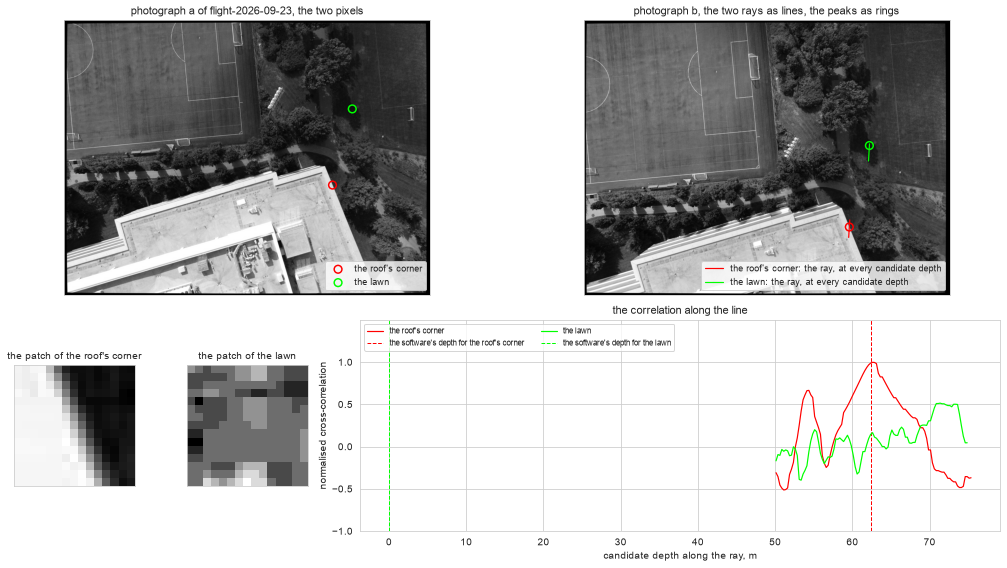

In [3]:
with rasterio.open("data/dsm_window.tif") as src:
    dsm = src.read(1, masked=True).filled(np.nan); dsm_transform = src.transform; cell_m = float(src.res[0])
offset = np.asarray(choices["offset"], dtype=float)                           # the map frame is the products' coordinate system minus this
rows, cols = dsm.shape
ground_level = float(np.nanpercentile(dsm, 25))                                # the lower quarter of the surface is the lawn and the paths
surface = np.nan_to_num(dsm, nan=ground_level)
tall = surface > ground_level + 8                                               # the roof and the crowns
labels, n_labels = ndi.label(tall)
roof = labels == np.argmax(ndi.sum(tall, labels, range(1, n_labels + 1))) + 1  # the largest tall region is the roof
roof_top = roof & (surface > np.median(surface[roof]) - 0.5)                   # its top, not its wall
centre_col = int((choices["window"]["centre"][0] - dsm_transform.c) / dsm_transform.a)
centre_row = int((dsm_transform.f - choices["window"]["centre"][1]) / -dsm_transform.e)
rr, cc = np.nonzero(roof_top)
nearest = np.argmin(np.hypot(rr - centre_row, cc - centre_col))
row_corner, col_corner = int(rr[nearest]), int(cc[nearest])                     # the corner that pokes into the window
onto = np.array(ndi.center_of_mass(roof)) - [row_corner, col_corner]
onto = onto / np.linalg.norm(onto)
row_roof, col_roof = int(round(row_corner + onto[0] * 0.5 / cell_m)), int(round(col_corner + onto[1] * 0.5 / cell_m))   # half a metre onto the roof
rotation_a = rodrigues(pose_a[0]); centre_a = -rotation_a.T @ pose_a[1]        # where camera a was


def search_depths(u, v):
    # the candidates for one pixel: the software's range, cut two metres under the ground level, below which no point of the ray can lie
    ray = rotation_a.T @ pixel_rays(u, v, pinhole, sample_w, sample_h)
    to_ground = (ground_level - centre_a[2]) / ray[2]
    return depths[depths <= to_ground + 2]


def cell_point(r, c):
    # a cell of the surface model as a point of the map frame: its centre and its height
    return np.array([dsm_transform.c + (c + 0.5) * dsm_transform.a - offset[0], dsm_transform.f + (r + 0.5) * dsm_transform.e - offset[1], dsm[r, c]])


def pixel_of(point):
    # where a map-frame point lands in the undistorted sample of a, and how far from the camera it is
    u, v, d = project_brown(point, pose_a[0], pose_a[1], pinhole, sample_w, sample_h)
    return int(round(u[0])), int(round(v[0])), float(d[0])


# the lawn: cells at the ground level with nothing higher within 5 m, sampled every metre, the least contrast in the photograph
open_lawn = ndi.maximum_filter(surface, size=int(round(5 / cell_m)) | 1) < ground_level + 0.5
step = int(round(1.0 / cell_m))
lawn_rows, lawn_cols = np.meshgrid(np.arange(step // 2, rows, step), np.arange(step // 2, cols, step), indexing="ij")
lawn_rows, lawn_cols = lawn_rows[open_lawn[lawn_rows, lawn_cols]], lawn_cols[open_lawn[lawn_rows, lawn_cols]]
contrast = []
for r, c in zip(lawn_rows, lawn_cols):
    u, v, _ = pixel_of(cell_point(r, c))
    contrast.append(grey_a[v - 7:v + 8, u - 7:u + 8].std() if 10 <= u < sample_w - 10 and 10 <= v < sample_h - 10 else np.inf)
flattest = int(np.argmin(contrast))
row_lawn, col_lawn = int(lawn_rows[flattest]), int(lawn_cols[flattest])

curves = {}
for label, (r, c) in {"the roof's corner": (row_roof, col_roof), "the lawn": (row_lawn, col_lawn)}.items():
    u, v, d_surface = pixel_of(cell_point(r, c))
    candidates = search_depths(u, v)
    ncc = ncc_depth(grey_a, grey_b, u, v, pose_a, pose_b, pinhole, sample_w, sample_h, candidates)
    peak = int(np.nanargmax(ncc))
    d_software = float(depth_file["depth"][int(round(v / depth_scale)), int(round(u / depth_scale))])
    rivals = int(((ncc >= ncc[peak] - 0.05) & (np.abs(candidates - candidates[peak]) > choices["depth_step_m"])).sum())
    curves[label] = dict(u=u, v=v, candidates=candidates, ncc=ncc, peak=peak, d_surface=d_surface, d_software=d_software)
    print(f"{label:18} pixel ({u}, {v}), patch contrast {grey_a[v - 7:v + 8, u - 7:u + 8].std():5.1f}, {len(candidates)} candidate depths: the surface model puts it {d_surface:.2f} m from the camera, "
          f"the correlation peaks at {candidates[peak]:.2f} m with {ncc[peak]:.2f}, the software's depth map says {d_software:.2f} m; {rivals} other depth(s) beyond one step correlate within 0.05 of the peak")

fig = plt.figure(figsize=(14, 8))
grid = fig.add_gridspec(2, 6, height_ratios=[1.3, 1])
ax_a, ax_b = fig.add_subplot(grid[0, :3]), fig.add_subplot(grid[0, 3:])
ax_a.imshow(grey_a, cmap="gray"); ax_b.imshow(grey_b, cmap="gray")
colours = {"the roof's corner": "red", "the lawn": "lime"}
for k, (label, cv) in enumerate(curves.items()):
    ax_a.scatter(cv["u"], cv["v"], s=60, facecolor="none", edgecolor=colours[label], linewidth=1.5, label=label)
    X = centre_a[None, :] + cv["candidates"][:, None] * (rotation_a.T @ pixel_rays(cv["u"], cv["v"], pinhole, sample_w, sample_h))[None, :]
    ub, vb, _ = project_brown(X, pose_b[0], pose_b[1], pinhole, sample_w, sample_h)
    ax_b.plot(ub, vb, color=colours[label], linewidth=1.2, label=f"{label}: the ray, at every candidate depth")
    ax_b.scatter(ub[cv["peak"]], vb[cv["peak"]], s=60, facecolor="none", edgecolor=colours[label], linewidth=1.5)
    ax_patch = fig.add_subplot(grid[1, k])
    ax_patch.imshow(grey_a[cv["v"] - 7:cv["v"] + 8, cv["u"] - 7:cv["u"] + 8], cmap="gray", interpolation="nearest"); ax_patch.set_xticks([]); ax_patch.set_yticks([])
    ax_patch.set_title(f"the patch of {label}", fontsize=10)
ax_a.set_title(f"photograph a of {flight['label']}, the two pixels", fontsize=11); ax_a.legend(loc="lower right", fontsize=9)
ax_b.set_title("photograph b, the two rays as lines, the peaks as rings", fontsize=11); ax_b.legend(loc="lower right", fontsize=9)
for ax in (ax_a, ax_b):
    ax.set_xticks([]); ax.set_yticks([])
ax_c = fig.add_subplot(grid[1, 2:])
for label, cv in curves.items():
    ax_c.plot(cv["candidates"], cv["ncc"], color=colours[label], linewidth=1.2, label=label)
    ax_c.axvline(cv["d_software"], color=colours[label], linestyle="--", linewidth=1, label=f"the software's depth for {label}")
ax_c.set_xlabel("candidate depth along the ray, m"); ax_c.set_ylabel("normalised cross-correlation"); ax_c.set_ylim(-1, 1.5); ax_c.set_yticks([-1, -0.5, 0, 0.5, 1])
ax_c.set_title("the correlation along the line", fontsize=11); ax_c.legend(loc="upper left", fontsize=8, ncol=2)
fig.tight_layout()

Read the two printed lines against each other, and then the figure. Each line gives the pixel, the contrast of its patch, how many candidate depths were left once the ray was cut at the ground, then three depths and a count. The first depth is where the surface model of 03b-06 puts that cell, the second is where our own correlation peaks, and the third is the software's depth map at the same pixel; on the roof's corner the three should agree to within a step or so, and the count of rivals, other depths well away from the peak that correlate almost as well, is the honest measure of how sure the search was. Where a rival appears on the roof's corner, look at where the ring sits in photograph b and what the line crosses there: a straight edge looks the same at every point along it, and the roof's edge and the edge of its shadow on the ground look alike, so wherever the line crosses another such edge the patch scores well again. That is the aperture problem, and the software escapes it by matching against several neighbours at once, which the section on its depth map names. On the lawn the patch contrast is a few grey levels, the peak is low and the rivals are many, and the second and third depths can disagree by more than a step or agree by luck; either way no single depth stands out along that line, which is the lecture's failure of uniqueness. What the software's depth map says there it says because it looked at several neighbours with larger patches and smoothed across pixels, and its confidence, which the third section opens, is where it admits how sure it was.

In the figure, the top row is the geometry. The rings in photograph a are the two pixels, and the two lines in photograph b are their rays drawn at every candidate depth, which is the epipolar line of 03b-03 sampled in depth rather than in pixels; the rings on the lines mark the peaks. Below, the two patches are what was correlated, and the curves are the correlation at every step, with the software's depth as a dashed line of the same colour. One curve rises to a peak that stands over its dashed line, the other wanders, and how far each curve's peak stands above its rivals is the whole difference between a measurement and a guess.

## Forty pixels, one number

One pixel is an anecdote. The cell below draws four hundred candidate pixels at random from those where the software's depth map is valid and its confidence is above its median, keeps the ones whose patch in photograph a has some contrast, and runs the search on the first forty that qualify, exactly as the ground truth did with the same seed, and over the software's whole range of depths this time, without our prior about the ground, so that the single pair is judged on its own. For each it compares the depth at the peak with the software's depth at that pixel. Two numbers summarise the forty, the share within half a metre and the median absolute difference:

40 pixels searched   reference 40
87.5% of them within half a metre of the software's depth   reference 87.5%
the median absolute difference is 0.20 m   reference 0.2


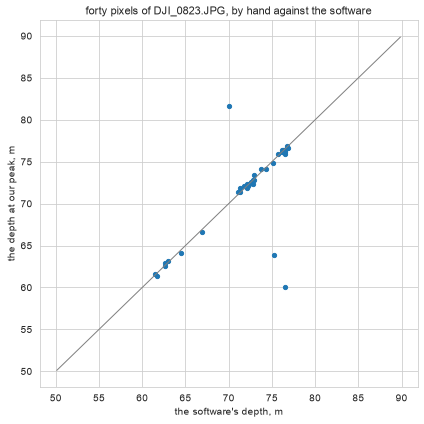

In [4]:
depth = depth_file["depth"]; valid = depth > 0
confidence = depth_file["confidence"].astype(np.float32)
rng = np.random.default_rng(20260930)
rows_ok, cols_ok = np.nonzero(valid & (confidence > np.median(confidence[valid])))
pick = rng.choice(len(rows_ok), min(400, len(rows_ok)), replace=False)
tested, hits, errors, pairs = 0, 0, [], []
for k in pick:
    r, c = int(rows_ok[k]), int(cols_ok[k])
    u, v = int(round(c * depth_scale)), int(round(r * depth_scale))                 # the depth map pixel as a sample pixel
    if not (10 <= u < sample_w - 10 and 10 <= v < sample_h - 10):
        continue
    if grey_a[v - 7:v + 8, u - 7:u + 8].std() < 8:                                  # a patch with no contrast has no peak to find
        continue
    ncc = ncc_depth(grey_a, grey_b, u, v, pose_a, pose_b, pinhole, sample_w, sample_h, depths)
    if np.all(np.isnan(ncc)):
        continue
    best = depths[int(np.nanargmax(ncc))]
    errors.append(abs(best - float(depth[r, c]))); pairs.append((float(depth[r, c]), best))
    tested += 1; hits += int(abs(best - float(depth[r, c])) <= 0.5)
    if tested >= 40:
        break
search = reference["depth"]["search"]
print(f"{tested} pixels searched   reference {search['pixels']}")
print(f"{hits / tested:.1%} of them within half a metre of the software's depth   reference {search['within_half_metre_share']:.1%}")
print(f"the median absolute difference is {np.median(errors):.2f} m   reference {search['median_abs_error_m']}")

pairs = np.array(pairs)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pairs[:, 0], pairs[:, 1], s=18, color="tab:blue")
lo, hi = depths[0], depths[-1]
ax.plot([lo, hi], [lo, hi], color="grey", linewidth=1)
ax.set_xlabel("the software's depth, m"); ax.set_ylabel("the depth at our peak, m")
ax.set_title(f"forty pixels of {choices['pair']['a']}, by hand against the software", fontsize=11)
fig.tight_layout()

Three lines. The first is the count, and it is forty unless the flight has too few textured pixels with a confident depth, which would itself be a finding. The second is the share of them on which a single pair, a 15 by 15 patch and a plain correlation land within half a metre of what the software found with its neighbours, its normals and its smoothing, and the third is how far off the typical one is; both are printed beside the reference so that the numbers of the class flight can be read against the pre-flight's. In the scatter, the points on the diagonal are the pixels where the two agree, and every point far from it is a pixel where our single line search picked a rival peak or a patch that sat across a depth edge. Read the share with the failure in mind. Where the search works, it works on the pixels that had contrast, because the cell asked for that before it searched; the lawn was never in the forty.

## The software's depth map

The software's answer for this photograph is a depth map, three arrays of the same shape, at a quarter of the full frame on each side. The depth is metres along the camera's axis, zero where the software found nothing; the confidence is its own measure of how well the patches agreed; and the normal is the direction of the surface at each pixel, which is how the software searches. Its search is not a line search like ours but a patch match over planes: each pixel carries a candidate depth and a candidate normal, the patch is warped by that plane into the neighbours, good guesses spread to neighbouring pixels and random ones are tried, and the plane that agrees best across the neighbours wins. The file also carries the camera the map was made with, its matrix K scaled to the map's size, the rotation and the centre, and the names of the neighbours it searched against:

the depth map of DJI_0823.JPG, 1000 by 750 pixels
depth               50.11 to 89.86 m, median 73.12 m   reference 50.11 to 89.98, median 73.12
valid pixels        76.9%   reference 76.9%
confidence          median 4.54 over the valid pixels   reference 4.54
neighbours searched DJI_0822.JPG, DJI_0816.JPG, DJI_0815.JPG, DJI_0883.JPG   reference DJI_0822.JPG, DJI_0816.JPG, DJI_0815.JPG, DJI_0883.JPG
its camera          focal 637.2 pixels of the map, the block's calibrated focal at this size is 637.2; its centre is 0.000 m from the block's map-frame camera centre


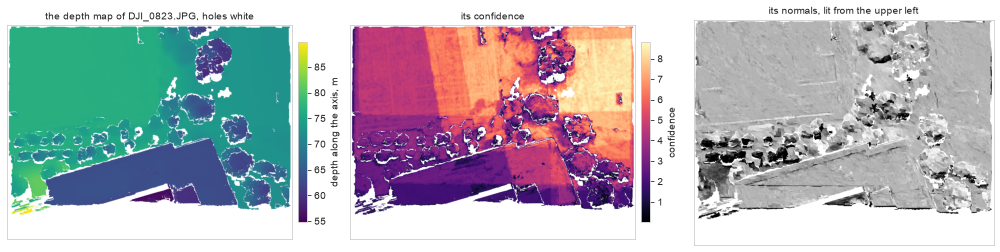

In [5]:
d = reference["depth"]
normals = depth_file["normals"].astype(np.float32) / 127                       # unit vectors, stored as signed bytes
K = depth_file["K"]
print(f"the depth map of {depth_file['name']}, {depth_w} by {depth_h} pixels")
print(f"depth               {depths[0]:.2f} to {depths[-1]:.2f} m, median {np.median(depth[valid]):.2f} m   reference {d['min_m']} to {d['max_m']}, median {d['median_m']}")
print(f"valid pixels        {valid.mean():.1%}   reference {d['valid_share']:.1%}")
print(f"confidence          median {np.median(confidence[valid]):.2f} over the valid pixels   reference {d['confidence_median']}")
print(f"neighbours searched {', '.join(str(n) for n in depth_file['neighbours'])}   reference {', '.join(d['neighbours'])}")
print(f"its camera          focal {K[0, 0]:.1f} pixels of the map, the block's calibrated focal at this size is {camera['focal_x'] * depth_w:.1f}; "
      f"its centre is {np.linalg.norm(depth_file['C'] - (-rodrigues(pose_a[0]).T @ pose_a[1])):.3f} m from the block's map-frame camera centre")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
shown = axes[0].imshow(np.where(valid, depth, np.nan), cmap="viridis")
fig.colorbar(shown, ax=axes[0], fraction=0.03, pad=0.02, label="depth along the axis, m")
axes[0].set_title(f"the depth map of {depth_file['name']}, holes white", fontsize=10)
shown = axes[1].imshow(np.where(valid, confidence, np.nan), cmap="magma")
fig.colorbar(shown, ax=axes[1], fraction=0.03, pad=0.02, label="confidence")
axes[1].set_title("its confidence", fontsize=10)
light = np.array([-0.5, -0.5, -0.7]); light /= np.linalg.norm(light)           # a light from the upper left, towards the camera
shade = np.clip((normals @ light), 0, 1)
axes[2].imshow(np.where(valid, shade, np.nan), cmap="gray", vmin=0, vmax=1)
axes[2].set_title("its normals, lit from the upper left", fontsize=10)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

The printed lines are the file's own account of itself. The depth range is the one our search used; the median depth is about the flying height, since most of a nadir photograph is ground. The valid share is how much of the frame the software was prepared to answer for, and the holes are where it was not; find them in the left panel and say what is under them, the deep shade, the water, the frame's edges that no neighbour saw. The confidence panel is the map of how sure it was, and it should be dark on the lawn and bright on edges and texture, which is the forty-pixel lesson drawn for every pixel at once. The neighbours are the photographs the software matched this one against, and they should be the pair's partner and the next strongest partners of 03b-03. The last line is a check that ties this file to the block of 03b-04: the depth map's own camera is the map-frame pose, with the focal scaled to the map's size, and its centre coincides with the block's.

The third panel is the normals, drawn as if a lamp stood at the upper left. A flat lawn is one grey, a roof is another, and the crowns are speckled because every leaf faces a different way. This is the difference between a line search and a patch match. Our search assumed the patch looks the same from both photographs, which is true for a flat patch seen from nearly above and false on a slope; the software's planes bend the patch to the surface before comparing, and the normals are what it found while doing so.

## From a depth map to a cloud

A depth map is a cloud in disguise. Each valid pixel and its depth is one point: the pixel becomes a direction through the inverse of K, the direction times the depth is the point in the camera's frame, and the rotation transposed plus the centre carries it into the map frame, the same frame as every product from here on. The cell does that for every valid pixel and draws the cloud of this one photograph in plan, with the window's rectangle on it:

576,382 points from one photograph, 77% of its depth map's pixels
they span 85 to 196 m east and -93 to 36 m north of the map frame's origin, -93.7 to -74.0 m in height
124,620 of them fall in the window; there they sit a median of -0.07 m from the surface model, with half of them within 0.08 m of it


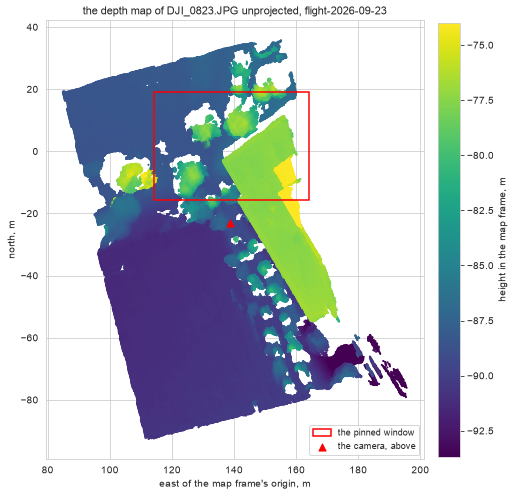

In [6]:
rows_v, cols_v = np.nonzero(valid)
pixels = np.column_stack([cols_v, rows_v, np.ones(len(rows_v))]).astype(float)   # u, v, 1 for every valid pixel
directions = pixels @ np.linalg.inv(K).T                                          # through K inverse: rays with third component one
in_camera = directions * depth[rows_v, cols_v][:, None]                            # times the depth along the axis
cloud = in_camera @ depth_file["R"] + depth_file["C"]                              # R transposed, then the centre: the map frame
cxl, cyl = choices["window"]["centre_local"]; hw, hh = choices["window"]["half_m"]

# the check: where the cloud crosses the window, its heights against the surface model of 03b-06 at the same cells
inside = (np.abs(cloud[:, 0] - cxl) < hw) & (np.abs(cloud[:, 1] - cyl) < hh)
r_dsm = ((dsm_transform.f - offset[1] - cloud[inside, 1]) / -dsm_transform.e).astype(int).clip(0, rows - 1)
c_dsm = ((cloud[inside, 0] - (dsm_transform.c - offset[0])) / dsm_transform.a).astype(int).clip(0, cols - 1)
gap = cloud[inside, 2] - dsm[r_dsm, c_dsm]
print(f"{len(cloud):,} points from one photograph, {valid.mean():.0%} of its depth map's pixels")
print(f"they span {cloud[:, 0].min():.0f} to {cloud[:, 0].max():.0f} m east and {cloud[:, 1].min():.0f} to {cloud[:, 1].max():.0f} m north of the map frame's origin, {np.percentile(cloud[:, 2], 1):.1f} to {np.percentile(cloud[:, 2], 99):.1f} m in height")
print(f"{inside.sum():,} of them fall in the window; there they sit a median of {np.nanmedian(gap):+.2f} m from the surface model, with half of them within {np.nanpercentile(np.abs(gap), 50):.2f} m of it")

fig, ax = plt.subplots(figsize=(11, 7))
shown = ax.scatter(cloud[::2, 0], cloud[::2, 1], c=cloud[::2, 2], s=1, cmap="viridis", vmin=np.percentile(cloud[:, 2], 1), vmax=np.percentile(cloud[:, 2], 99))
fig.colorbar(shown, ax=ax, fraction=0.03, pad=0.02, label="height in the map frame, m")
ax.add_patch(plt.Rectangle((cxl - hw, cyl - hh), 2 * hw, 2 * hh, facecolor="none", edgecolor="red", linewidth=1.5, label="the pinned window"))
ax.scatter(depth_file["C"][0], depth_file["C"][1], s=50, marker="^", color="red", label="the camera, above")
ax.set_aspect("equal"); ax.set_xlabel("east of the map frame's origin, m"); ax.set_ylabel("north, m"); ax.legend(loc="lower right", fontsize=9)
ax.set_title(f"the depth map of {depth_file['name']} unprojected, {flight['label']}", fontsize=11)
fig.tight_layout()

The first line counts the points, which is the number of valid pixels, a few hundred thousand from one photograph against the few thousand features 03b-02 found in it; that ratio is what dense means. The second gives the cloud's extent, and it is the photograph's footprint on the ground, the rectangle 03b-01 predicted from the flying height turned by the heading, with the height of the ground and of what stands on it. The third line is the check. Where this cloud crosses the window, its points should lie on the surface model that 03b-06 builds from all the photographs together: read the median for a systematic offset, which would mean the unprojection or the frame was wrong, and the half-width for how tightly one photograph's depths sit on the surface that all of them made. A median of a few centimetres below zero would not be an error either, since the surface model takes the highest point per cell and this photograph's points are not always the highest.

In the plan view, the cloud is one photograph's worth of ground with the camera's own position marked above it, and its colour is height. The footpaths and the lawn are one level, the roof another, and the crowns the brightest. The fused cloud of the next section is this from every photograph that sees the window, merged and filtered.

## The fused cloud in the window

The software fused the depth maps of every photograph into one cloud and filtered it, keeping a point only where several depth maps agreed and dropping the rest. The kit carries the part of that filtered cloud that falls inside the pinned window, with each point's colour, the number of depth maps that agreed on it, which the file calls its views, and the class the software gave it later when it separated the ground from what stands on it. Here it is in plan, twice, and counted:

356,691 points in the window, of 12,713,513 in the whole filtered cloud   reference 356,691 of 12,713,513
203.8 points per square metre over 1750 square metres   reference 203.8
views per point: 2 to 10, median 3   reference 2 to 10, median 3
   seen by 2 depth maps   129,403 points   reference 129,403
   seen by 3 depth maps    82,620 points   reference  82,620
   seen by 4 depth maps    72,956 points   reference  72,956
   seen by 5 depth maps    25,520 points   reference  25,520
   seen by 6 depth maps    16,468 points   reference  16,468
   seen by 7 depth maps    10,674 points   reference  10,674
   seen by 8 depth maps    11,337 points   reference  11,337
   seen by 9 depth maps     7,535 points   reference   7,535
   seen by 10 depth maps       178 points   reference     178


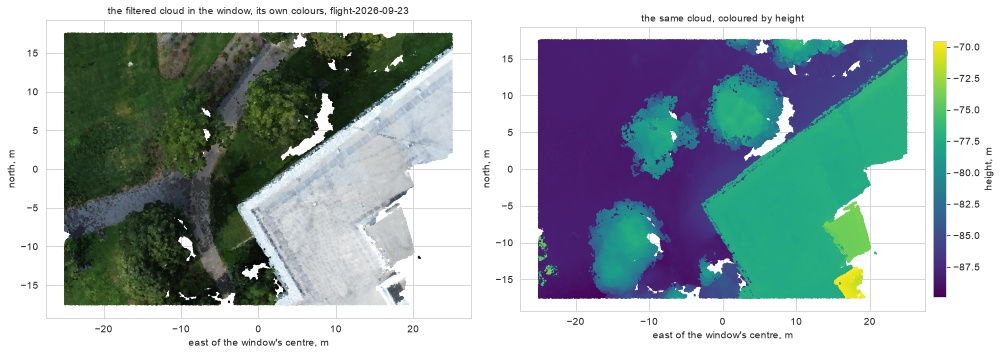

In [7]:
dense = np.load("data/dense_window.npz")
xyz = dense["xyz"].astype(float); rgb = dense["rgb"]; views = dense["views"].astype(int)
hw, hh = [float(v) for v in dense["half_m"]]; area = 4 * hw * hh
xyz_local = xyz + np.array([float(dense["centre_local"][0]), float(dense["centre_local"][1]), 0.0])   # the map frame, like the depth map's cloud
e = reference["dense"]
print(f"{len(xyz):,} points in the window, of {int(dense['n_total']):,} in the whole filtered cloud   reference {e['points']:,} of {e['of_total']:,}")
print(f"{len(xyz) / area:.1f} points per square metre over {area:.0f} square metres   reference {e['per_m2']}")
print(f"views per point: {views.min()} to {views.max()}, median {np.median(views):.0f}   reference {e['views']['min']} to {e['views']['max']}, median {e['views']['median']:.0f}")
for k in range(views.min(), views.max() + 1):
    print(f"   seen by {k} depth maps   {int((views == k).sum()):7,} points   reference {e['views']['histogram'].get(str(k), 0):7,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
axes[0].scatter(xyz[:, 0], xyz[:, 1], c=rgb / 255, s=1)
axes[0].set_title(f"the filtered cloud in the window, its own colours, {flight['label']}", fontsize=10)
shown = axes[1].scatter(xyz[:, 0], xyz[:, 1], c=xyz[:, 2], s=1, cmap="viridis")
fig.colorbar(shown, ax=axes[1], fraction=0.03, pad=0.02, label="height, m")
axes[1].set_title("the same cloud, coloured by height", fontsize=10)
for ax in axes:
    ax.set_aspect("equal"); ax.set_xlabel("east of the window's centre, m"); ax.set_ylabel("north, m")
fig.tight_layout()

The count is the window's share of the whole filtered cloud, and the second line turns it into a density, points per square metre of ground, which is the number to remember when you plan a flight: it is what the pixel size, the overlap and the filtering leave you. The views are the filter made visible. Every point in the file was seen by at least two depth maps, because that is where the filter draws its line, and the table says how many were seen by three, four and more; read the shape of it, most points at the low end and a tail towards the number of photographs that overlapped here. In the two pictures, the left is the cloud as a photograph, the right the same points by height, and the roof, the crowns and the paths are all there at a density that the sparse cloud of 03b-04 could not have drawn.

The density is not the same everywhere, and the next cell asks where it differs. It grids the window at one metre and counts the points in each cell, then reads the surface model minus the terrain model at the same cells, both shipped with the kit and both built in 03b-06, to separate the cells at the ground from the cells that stand more than 3 m above it. One caution for reading it, which 03b-06 makes plain: the terrain model here is the software's, and the software's filter kept the large flat roof as ground, so inside the roof the surface minus the terrain is zero and the roof's interior counts among the ground cells; what stands above 3 m in this split is the crowns and the band along the roof's edge. The cell also prints the classes the software gave the points, and a section through the window, a strip one metre wide through its centre, drawn as east against height:

178.1 points per square metre on the 1094 cells at the ground, which are 62.5% of the window   reference 178.1, 62.5%
303.3 points per square metre on the 440 cells that stand more than 3 m above the terrain   reference 303.3
   class 0 unmatched           0.0% of the points, seen by a median of 4 depth maps   reference 0.0%
   class 1 unclassified        1.2% of the points, seen by a median of 2 depth maps   reference 1.2%
   class 2 ground             64.6% of the points, seen by a median of 4 depth maps   reference 64.6%
   class 3 low vegetation     25.4% of the points, seen by a median of 2 depth maps   reference 25.4%
   class 6 building            8.9% of the points, seen by a median of 3 depth maps   reference 8.9%


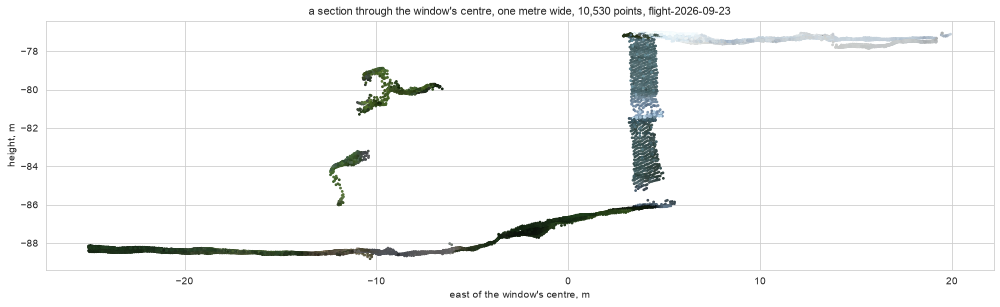

In [8]:
with rasterio.open("data/dtm_window.tif") as src:
    dtm = src.read(1, masked=True).filled(np.nan)
height = dsm - dtm                                                                  # the height of things, 03b-06's product
bounds_local = (dsm_transform.c - offset[0], dsm_transform.f + rows * dsm_transform.e - offset[1], dsm_transform.c + cols * dsm_transform.a - offset[0], dsm_transform.f - offset[1])
col_i = np.floor((xyz_local[:, 0] - bounds_local[0]) / 1.0).astype(int)
row_i = np.floor((bounds_local[3] - xyz_local[:, 1]) / 1.0).astype(int)
n_cols_1m, n_rows_1m = int((bounds_local[2] - bounds_local[0]) // 1.0), int((bounds_local[3] - bounds_local[1]) // 1.0)
in_grid = (col_i >= 0) & (col_i < n_cols_1m) & (row_i >= 0) & (row_i < n_rows_1m)
counts_1m = np.zeros((n_rows_1m, n_cols_1m), int)
np.add.at(counts_1m, (row_i[in_grid], col_i[in_grid]), 1)
step = int(round(1.0 / cell_m))
height_1m = height[: n_rows_1m * step, : n_cols_1m * step].reshape(n_rows_1m, step, n_cols_1m, step).mean(axis=(1, 3))
surface_1m = surface[: n_rows_1m * step, : n_cols_1m * step].reshape(n_rows_1m, step, n_cols_1m, step).mean(axis=(1, 3))
ground_cells = np.nan_to_num(height_1m) < 0.5
above_cells = np.nan_to_num(height_1m) > 3.0
print(f"{counts_1m[ground_cells].mean():.1f} points per square metre on the {ground_cells.sum()} cells at the ground, which are {ground_cells.mean():.1%} of the window   reference {e['per_m2_on_ground_cells']}, {e['ground_cells_share']:.1%}")
print(f"{counts_1m[above_cells].mean():.1f} points per square metre on the {above_cells.sum()} cells that stand more than 3 m above the terrain   reference {e['per_m2_above_3m']}")
asprs = {0: "unmatched", 1: "unclassified", 2: "ground", 3: "low vegetation", 4: "medium vegetation", 5: "high vegetation", 6: "building", 7: "noise", 9: "water"}
if "classification" in dense.files:
    classes = dense["classification"].astype(int)
    for k in np.unique(classes):
        print(f"   class {k} {asprs.get(int(k), 'other'):17} {(classes == k).mean():6.1%} of the points, seen by a median of {np.median(views[classes == k]):.0f} depth maps   reference {e.get('class_share', {}).get(str(k), float('nan')):.1%}")
else:
    classes = np.zeros(len(xyz), int)
    print("this flight's cloud ships without classes")

strip = np.abs(xyz[:, 1]) < 0.5                                                     # one metre wide, through the window's centre, east to west
fig, ax = plt.subplots(figsize=(14, 4.2))
ax.scatter(xyz[strip, 0], xyz[strip, 2], c=rgb[strip] / 255, s=3)
ax.set_xlabel("east of the window's centre, m"); ax.set_ylabel("height, m"); ax.set_aspect("equal")
ax.set_title(f"a section through the window's centre, one metre wide, {strip.sum():,} points, {flight['label']}", fontsize=11)
fig.tight_layout()

Two densities and a table of classes. The first line is the density on the cells at the ground and how much of the window they are, the second the density on the cells that stand above 3 m, and the point of printing them together is to see which is larger and by how much. A crown holds more surface per square metre of map than a lawn does, because its surface is steep and folded, and it holds texture that every depth map could match, so it can carry more points; a lawn is flat and blank and the depth maps that gave up there are the holes of the third section. The class table says what the software later decided each point was, with the ASPRS codes that every point cloud format shares, and beside each class the median number of depth maps that saw its points. Read which class was seen by the most, and ask why the tall things carry fewer views than the ground: a roof or a crown hides its own far side and the ground beside it from every camera on the other side, and a point seen from fewer places is a point the filter trusts less.

The section is the window cut open. The lawn and the paths are the floor, a clump floating above it is a crown with nothing beneath it where the photographs could not see into the shade, and the roof is the flat line at the top with the wall dropping from it, a column of points that the photographs taken from the far side of the building saw as a face. This is what a surface model will flatten into one height per cell in 03b-06, and the section is where you can see what that flattening keeps and what it throws away.

## Your turn

Measure the density on the roof alone, the way the cell above measured the ground and the tall cells. The roof's cells are the one metre cells where most of the points carry the building class, and if a flight's cloud has no classes the cells whose surface stands 8 m or more above the window's ground level will do instead. Compare it with the density at the ground, and say which surface the depth maps found easier and why.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [9]:
# Your attempt. counts_1m holds the points per one metre cell, row_i and col_i the cell of every point, in_grid which points fall in the grid,
# classes the ASPRS code of every point, surface_1m the surface model averaged over the same cells and ground_level the window's ground level.
#
# on_roof = in_grid & (classes == ___)                                  # the ASPRS code of a building
# building_1m = np.zeros_like(counts_1m)
# np.add.at(building_1m, (row_i[on_roof], col_i[on_roof]), 1)
# roof_cells = building_1m > counts_1m * ___                            # cells where more than half the points are building
# if not roof_cells.any():
#     roof_cells = surface_1m > ground_level + ___                       # without classes: cells whose surface stands 8 m over the lawn
# print(f"{counts_1m[roof_cells].mean():.1f} points per square metre on the roof's {roof_cells.sum()} cells, against {counts_1m[ground_cells].mean():.1f} at the ground")

## Check your understanding

1. The search for a pixel's depth ran along one line in the second photograph rather than over the whole picture. Say what fixes that line, and what would go wrong with the search if the two camera poses of 03b-04 were a metre off.
2. The lawn pixel's correlation curve had no peak that stood clear of its rivals. Say what property of the patch causes that, and name two things in a town scene besides a lawn that would fail the same way.
3. The software's depth map carries a confidence for every pixel. Say what the software compares to arrive at it, and why a pixel with a high confidence can still be wrong.
4. The class table printed the median number of depth maps that saw the points of each class. Say which way round it came out for the ground against the roof and the crowns, and give the geometric reason.

## Where we are

You have run the dense search yourself: a pixel as a ray, the ray as a line in the second photograph, the correlation along it and the peak that is the match, and the flat curve on the lawn that is the failure of uniqueness. You have tested the search on forty pixels against the software's answer and seen where the single pair holds and where it does not, opened the depth map with its confidence and its normals and read what the software's patch match does beyond a line search, unprojected one depth map into a cloud of hundreds of thousands of points and checked it against the surface model, and counted the fused cloud in the window by density, by views and by class.

The habit worth keeping: before you trust a height from photographs, ask what the pixel under it looked like, because a depth on texture is a measurement and a depth on a blank surface is an interpolation, however confidently the file states it.

In 03b-06 the cloud becomes a surface.

## Further resources

Nothing in this course requires anything below.

Hirschmüller's semi-global matching is the classic account of dense stereo along epipolar lines with a smoothness term, and the algorithm behind most photogrammetric depth maps before patch match: https://elib.dlr.de/55367/. The patch match over planes that OpenMVS uses descends from Bleyer, Rhemann and Rother's PatchMatch Stereo: https://www.bmva.org/bmvc/2011/proceedings/paper14/index.html, and OpenMVS itself, with its depth map format and its fusion, is at https://github.com/cdcseacave/openMVS. Szeliski's free textbook covers stereo correspondence in chapter 12: https://szeliski.org/Book/

OpenDroneMap's documentation describes the dense stage, its depth map resolution and its filtering options: https://docs.opendronemap.org/arguments/, and OpenSfM's the undistortion that precedes it: https://opensfm.org/docs/

The photographs, the depth map, the cloud and the models are the course's own flight, published under CC BY 4.0.

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The density on the roof's cells, from the files themselves so that the cell stands on its own:

```python
import json
import numpy as np
import rasterio

choices = json.load(open("data/flight.json"))["p03b"]
dense = np.load("data/dense_window.npz")
xyz = dense["xyz"].astype(float) + np.array([float(dense["centre_local"][0]), float(dense["centre_local"][1]), 0.0])
with rasterio.open("data/dsm_window.tif") as src:
    dsm = src.read(1, masked=True).filled(np.nan); tr = src.transform; cell_m = float(src.res[0])
with rasterio.open("data/dtm_window.tif") as src:
    dtm = src.read(1, masked=True).filled(np.nan)
ox, oy = choices["offset"]
rows, cols = dsm.shape
minx, maxy = tr.c - ox, tr.f - oy
n_cols, n_rows = int((cols * tr.a) // 1.0), int((rows * -tr.e) // 1.0)
col_i = np.floor((xyz[:, 0] - minx) / 1.0).astype(int); row_i = np.floor((maxy - xyz[:, 1]) / 1.0).astype(int)
in_grid = (col_i >= 0) & (col_i < n_cols) & (row_i >= 0) & (row_i < n_rows)
counts = np.zeros((n_rows, n_cols), int); np.add.at(counts, (row_i[in_grid], col_i[in_grid]), 1)
step = int(round(1.0 / cell_m))
height_1m = (dsm - dtm)[: n_rows * step, : n_cols * step].reshape(n_rows, step, n_cols, step).mean(axis=(1, 3))
ground_cells = np.nan_to_num(height_1m) < 0.5
if "classification" in dense.files:
    on_roof = in_grid & (dense["classification"].astype(int) == 6)
    building = np.zeros_like(counts); np.add.at(building, (row_i[on_roof], col_i[on_roof]), 1)
    roof_cells = building > counts * 0.5
else:
    ground_level = float(np.nanpercentile(dsm, 25))
    surface_1m = np.nan_to_num(dsm, nan=ground_level)[: n_rows * step, : n_cols * step].reshape(n_rows, step, n_cols, step).mean(axis=(1, 3))
    roof_cells = surface_1m > ground_level + 8
print(f"{counts[roof_cells].mean():.1f} points per square metre on the roof's {roof_cells.sum()} cells, against {counts[ground_cells].mean():.1f} at the ground")
```

Whichever way round the two densities come out, the reason is in the section of the last figure: the roof is flat gravel seen from nearly above by every photograph that covers it, and the ground beside it is partly hidden by the roof itself.